In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

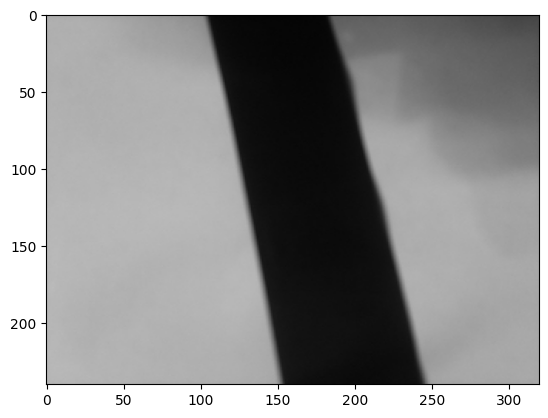

In [3]:
image = cv2.imread('line1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

Research notes:
- https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html
- https://z-uo.medium.com/line-detection-computer-vision-vs-deep-neural-network-27c6b40a14c8
- https://colab.research.google.com/drive/1x8Q9dJWsCm4IkJEDjbV7FfEO9nrzEP8m?usp=sharing
- https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
- [Canny Computerfile](https://www.youtube.com/watch?v=sRFM5IEqR2w)
- [Sobel Computerfile](https://www.youtube.com/watch?v=uihBwtPIBxM)

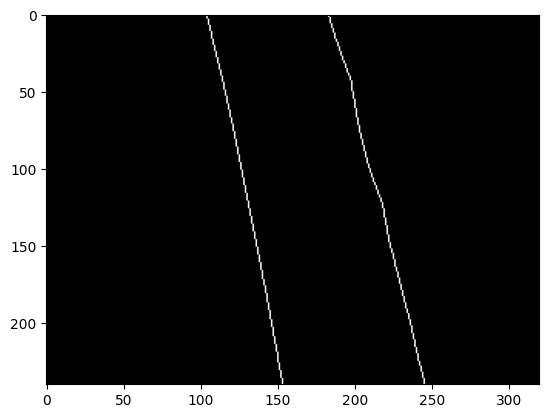

In [4]:
# Find edges with canny
edges = cv2.Canny(gray, 50, 200, None, 3)
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))


In [5]:

# The accumulator is a 2D array where each element corresponds to a potential line in the image.
# The first dimension corresponds to the distance from the origin (rho) and the second dimension corresponds to the angle (theta).
rho = 1 # Distance resolution of the accumulator in pixels
theta = np.pi / 180 # Angle resolution of the accumulator in radians
threshold = 50 # Accumulator threshold for the cv2.HoughLines function

minLineLength = 50 # Minimum line length. Line segments shorter than this are rejected
maxLineGap = 10 # Maximum allowed gap between points on the same line to link them

lines = cv2.HoughLinesP(edges, rho, theta, threshold, None, minLineLength, maxLineGap)
lines

array([[[143, 186, 153, 239]],

       [[111,  28, 134, 136]],

       [[199,  54, 212, 108]],

       [[127, 105, 147, 203]],

       [[214, 111, 245, 237]]], dtype=int32)

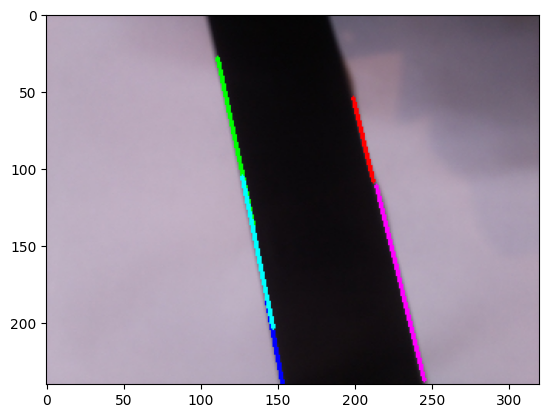

In [6]:
# Make a copy of the original image to draw lines on
with_lines = resized.copy()

# Colours
colors = [
    (255, 0, 0),  # Blue
    (0, 255, 0),  # Green
    (0, 0, 255),  # Red
    (255, 255, 0),  # Cyan
    (255, 0, 255),  # Magenta
    (0, 255, 255)   # Yellow
]

# Use matplotlib to plot the lines on the image
for line, color in zip(lines, colors * (len(lines) // len(colors) + 1)):
    x1, y1, x2, y2 = line[0]
    cv2.line(with_lines, (x1, y1), (x2, y2), color, 2)
plt.imshow(cv2.cvtColor(with_lines, cv2.COLOR_BGR2RGB))

In [7]:
# Use np to find the length in pixels of each line (pythagorean theorem)
lines_with_length = [
    np.hypot(lines[:, 0, 2] - lines[:, 0, 0], lines[:, 0, 3] - lines[:, 0, 1])
]



[[182   0]
 [186   0]
 [248 238]
 [244 239]]
[[103   0]
 [106   0]
 [155 238]
 [152 239]]
First rectangle: ((215.7384033203125, 119.04754638671875), (246.91085815429688, 3.9770872592926025), 75.41107940673828)
Mean rectangle: ((172, 119), (245, 3), 76.88525390625)
Box points: [[142   0]
 [145   0]
 [201 237]
 [198 238]]


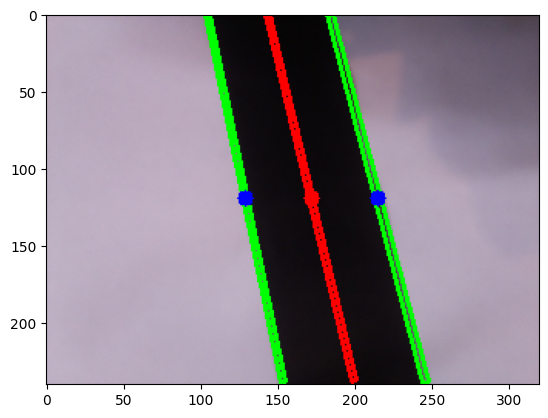

In [8]:
# Find contours in the edges image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the 2 largest contours
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
# Create a minAreaRect for each contour (center, (width, height), angle)
bound_rects = [cv2.minAreaRect(c) for c in contours]
# Plot the rects on a copied image
copy_image = resized.copy()
for rect in bound_rects:
    box = cv2.boxPoints(rect)
    box = np.intp(box)  # Convert to integer points
    print(box)
    cv2.drawContours(copy_image, [box], 0, (0, 255, 0), 2)
    # Add a blue dot on the origin of each rectangle
    cv2.circle(copy_image, tuple(map(int, rect[0])), 5, (255, 0, 0), -1)
# Find the mid point between the two centres
mid_point = np.mean([rect[0] for rect in bound_rects], axis=0).astype(int)
# Find the mean angle of the two rectangles
mean_angle = np.mean([rect[2] for rect in bound_rects])
# Draw a red dot on the mid point
cv2.circle(copy_image, tuple(mid_point), 5, (0, 0, 255), -1)
# Draw a rect with the mid point as the center, mean angle and the width and height as the mean of the two rectangles
mean_width = int(np.mean([rect[1][0] for rect in bound_rects]))
mean_height = int(np.mean([rect[1][1] for rect in bound_rects]))
mean_rect = (mid_point[0].item(), mid_point[1].item()), (mean_width, mean_height), mean_angle.item()

print("First rectangle:", bound_rects[0])
print("Mean rectangle:", mean_rect)
# Render numpy types into normal types for cv2
box = cv2.boxPoints(mean_rect)
box = np.intp(box)  # Convert to integer points
print("Box points:", box)
cv2.drawContours(copy_image, [box], 0, (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(copy_image, cv2.COLOR_BGR2RGB))

In [9]:
colors = {
    "RED": (255, 0, 0),
    "GREEN": (0, 255, 0),
    "BLUE": (0, 0, 255),
    "CYAN": (255, 255, 0),
    "MAGENTA": (255, 0, 255),
    "YELLOW": (0, 255, 255)
}

def plot_rot_rect(rot_rect, image):
    box = cv2.boxPoints(rot_rect)
    box = np.intp(box)  # Convert to integer points
    cv2.drawContours(image, [box], 0, colors["GREEN"], 2)
    # Circle the center of the rectangle
    center = tuple(map(int, rot_rect[0]))
    cv2.circle(image, center, 5, colors["RED"], -1)

def get_line_angle_and_centre(image):
    """
    Calculate the angle and center of the longest line in the image.
    :param image: The input image with a line.
    :return: A tuple containing the angle in degrees and the center point (x, y).
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 200, None, 3)
    
    # Find contours in the edges image
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # Find the two largest contours
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
    # Create a minAreaRect for each contour -> (center, (width, height), angle)
    bound_rects = [cv2.minAreaRect(c) for c in contours]    
    if not bound_rects:
        return None, None
    # Sometimes the rectangles are rotatied 90 degrees. Normalise them so
    # the the width is always the larger dimension
    for rect in bound_rects:
        if rect[1][0] < rect[1][1]:
            # Swap width and height
            bound_rects[bound_rects.index(rect)] = (
                rect[0], (rect[1][1], rect[1][0]), 
                (rect[2] + 90) % 180)
    
    for rect in bound_rects:
        plot_rot_rect(rect, image)
    # Find the mid point between the two centres
    mid_point = np.mean([rect[0] for rect in bound_rects], axis=0).astype(int)
    # Find the mean angle of the two rectangles
    mean_angle = np.mean([rect[2] for rect in bound_rects])
    return mean_angle, (mid_point[0].item(), mid_point[1].item())


def plot_image_with_lines(image, mean_angle, center):
    """
    Plot the image with lines drawn on it.
    :param image: The input image.
    :param mean_angle: The angle of the line in degrees.
    :param center: The center point (x, y) of the line.
    """
    copy_image = image.copy()
    # Draw a line at the mean angle
    length = 100  # Length of the line
    x1 = int(center[0] + length * np.cos(np.radians(mean_angle)))
    y1 = int(center[1] + length * np.sin(np.radians(mean_angle)))
    x2 = int(center[0] - length * np.cos(np.radians(mean_angle)))
    y2 = int(center[1] - length * np.sin(np.radians(mean_angle)))
    
    cv2.line(copy_image, (x1, y1), (x2, y2), colors["RED"], 2)
    cv2.circle(copy_image, center, 5, colors["GREEN"], -1)
    
    plt.imshow(cv2.cvtColor(copy_image, cv2.COLOR_BGR2RGB))

Could not find lines in carpet_noline.jpg.


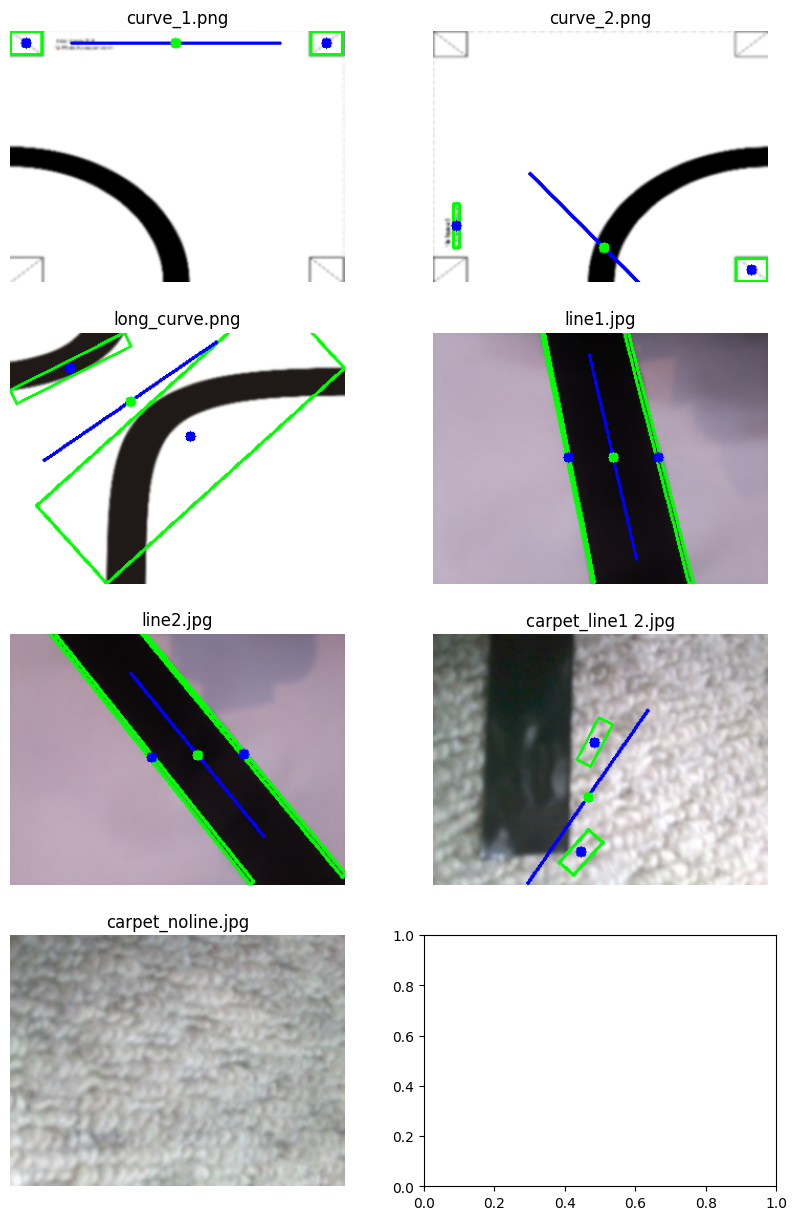

In [10]:
image_names = ['curve_1.png', 'curve_2.png', 'long_curve.png', 'line1.jpg', 'line2.jpg', 'carpet_line1 2.jpg', 'carpet_noline.jpg']
# Make a multiple plot of the images - 3 by 2 plot
fig, axs = plt.subplots(4, 2, figsize=(10, 15))
for n, (ax, image_name) in enumerate(zip(axs.flatten(), image_names)):
    # Select correct subplot
    plt.subplot(4, 2, n+1)
    ax.set_title(image_name)
    ax.axis('off')
    
    # Read the image
    image = cv2.imread(image_name)
    # Resize the image to 320x240
    image = cv2.resize(image, (320, 240))
    # Blur the image
    image = cv2.GaussianBlur(image, (5, 5), 0)
    mean_angle, center = get_line_angle_and_centre(image)
    if mean_angle is not None and center is not None:
        plot_image_with_lines(image, mean_angle, center)
    else:
        print(f"Could not find lines in {image_name}.")
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.axis('off')


Not stable enough to use in the book:
- Slow compared with simple diff
- Not accurate enough - less compared with simple diff
- However, it is finding more of the line than one row would